In [1]:
%load_ext autoreload
%autoreload 2

import os
os.getcwd()

'/output/cifar100-benchmark'

图片已保存为 matrix_rain.png


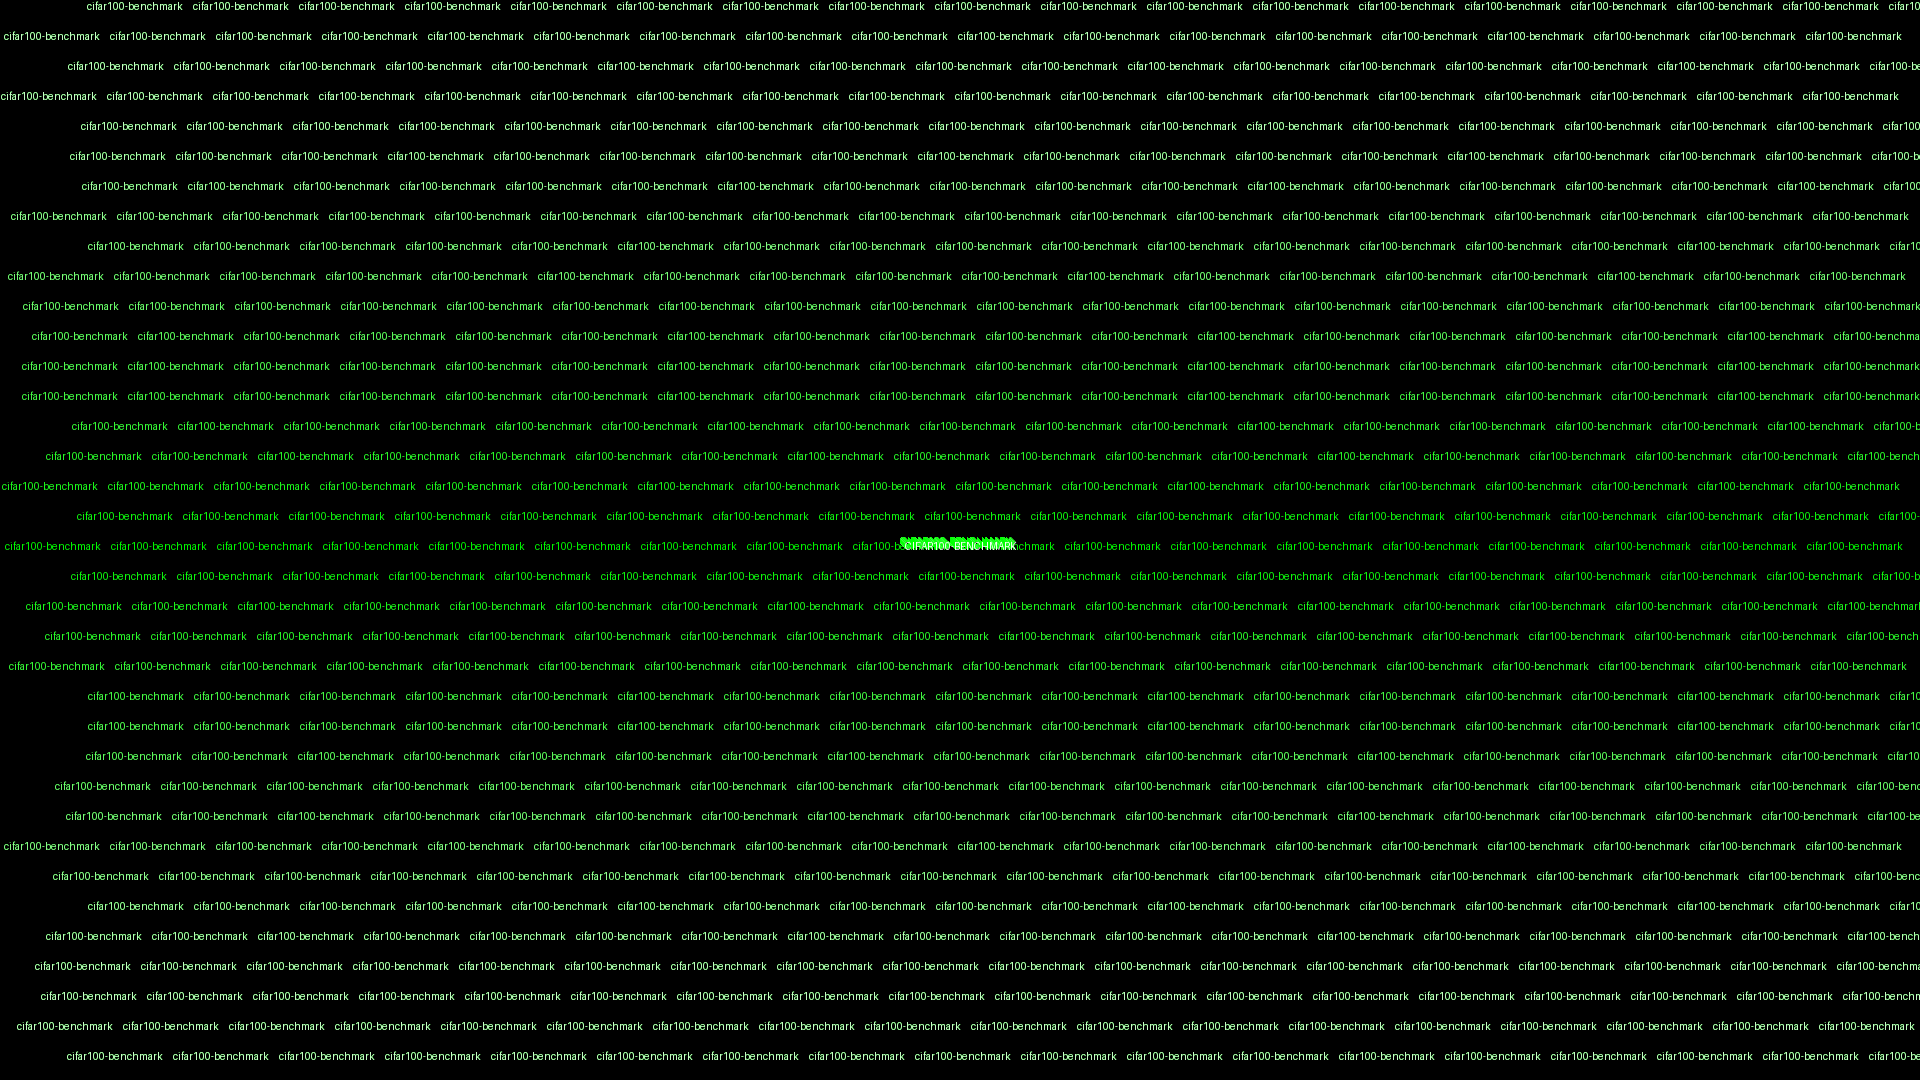

In [5]:
from PIL import Image, ImageDraw, ImageFont
import random
import numpy as np

def create_matrix_rain(width=1920, height=1080, text="cifar100-benchmark"):
    # 创建黑色背景
    image = Image.new('RGBA', (width, height), color='black')
    draw = ImageDraw.Draw(image)
    
    # 尝试加载字体，如果失败则使用默认字体
    try:
        normal_font = ImageFont.truetype("arial.ttf", 200)  # 普通文字大小
        highlight_font = ImageFont.truetype("arial.ttf", 400)  # 醒目文字大小
    except:
        normal_font = ImageFont.load_default()
        highlight_font = ImageFont.load_default()
    
    # 计算屏幕中心位置
    center_y = height / 2
    
    # 计算文字宽度和每行可容纳的文字数量
    text_width = draw.textlength(text, font=normal_font)
    texts_per_line = int(width / (text_width + 10))  # +10 为文字间距
    
    # 计算行间距，确保均匀分布
    line_height = 30
    num_lines = height // line_height
    
    # 绘制普通文字
    for line in range(num_lines):
        y = line * line_height
        
        # 计算与中心的距离，用于确定透明度
        distance = abs(y - center_y)
        max_distance = height / 2
        
        # 透明度基于距离计算（越靠近中心越不透明）
        alpha = int(255 * (1 - distance / max_distance))
        alpha = max(50, min(alpha, 255))  # 限制透明度范围
        
        # 为每一行生成随机偏移
        offset = random.randint(0, int(text_width))
        
        # 填充整行
        for i in range(texts_per_line):
            x = i * (text_width + 10) + offset
            x = x % width  # 确保文字在屏幕范围内
            
            # 绘制文本
            color = (0, 255, 0, alpha)  # 亮绿色，带透明度
            draw.text((x, y), text, font=normal_font, fill=color)
    
    # 在中间位置绘制醒目文字
    center_text = text.upper()  # 转为大写使其更醒目
    center_text_width = draw.textlength(center_text, font=highlight_font)
    center_x = (width - center_text_width) / 2
    
    # 为中心文字添加发光效果
    glow_colors = [
        (0, 255, 0, 50),  # 最外层光晕
        (0, 255, 0, 100),
        (0, 255, 0, 150),
        (0, 255, 0, 200),
        (0, 255, 0, 255)  # 最内层文字
    ]
    
    # 绘制发光效果
    for offset in range(5, 0, -1):
        for color in glow_colors:
            draw.text(
                (center_x - offset, center_y - offset),
                center_text,
                font=highlight_font,
                fill=color
            )
    
    # 最后绘制中心文字
    draw.text(
        (center_x, center_y),
        center_text,
        font=highlight_font,
        fill=(255, 255, 255, 255)  # 白色，完全不透明
    )
    
    # 保存图片
    image.save("images/matrix_rain.png", "PNG")
    print("图片已保存为 matrix_rain.png")
    
    # 显示
    image.show()
# 生成图片
create_matrix_rain()

In [2]:
import torchvision
import torchvision.transforms as transforms
import torch
from torch.utils.data import random_split

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# 加载完整训练集
full_trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)

# 将训练集按8:2比例分割为训练集和验证集
train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size
trainset, valset = random_split(full_trainset, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(valset, batch_size=4, shuffle=False)

# 测试集保持不变
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False)


Files already downloaded and verified
Files already downloaded and verified


In [3]:
from networks import CNN
from utils import check_model


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)
check_model(model, num_classes=100, batch_size=4, device=device)



device: cuda:0
batch_size: 4
num_classes: 100
Forward pass output shape: torch.Size([4, 100])
test_target shape: torch.Size([4])
Test loss: 4.5802
损失计算成功


In [4]:
from utils import train_model

model = CNN(num_classes=100, in_channels=3, dropout=0.5).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_epochs = 2


In [9]:
train_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    criterion,
    device,
    num_epochs,
    save_dir="logs/CNN",
    save_log=True,
    pretrained="/output/cifar100-benchmark/logs/CNN/log_4/best_model_top1:0.5055_in_epoch1.pth"
)

print("Training complete")

加载预训练模型: /output/cifar100-benchmark/logs/CNN/log_4/best_model_top1:0.5055_in_epoch1.pth
日志和模型将保存到: logs/CNN/log_5
Epoch 1/2


Training:   0%|          | 6/1250 [00:00<00:21, 57.41it/s, loss=4, top 1=0.33, top 5=0.665]    

Train Loss: 2.5674, Top 1: 0.3318, Top 5: 0.6556
Val Loss: 2.0042, Top 1: 0.4971, Top 5: 0.8075
当前最佳top1准确率: 0.4971 in epoch 1
Epoch 2/2


Train Loss: 2.5487, Top 1: 0.3354, Top 5: 0.6596
Val Loss: 2.0504, Top 1: 0.4855, Top 5: 0.7943
加载最佳模型，进行测试


Testing: 100%|██████████| 2500/2500 [00:09<00:00, 268.64it/s, loss=2.33, top 1=0.404, top 5=0.722]


Test Loss: 2.3303, Top 1: 0.4043, Top 5: 0.7222
Training complete


In [10]:
from utils import predict

predict(model, 
        test_loader, 
        device, 
        pretrained=None)

 

Top 1 Accuracy: 0.4043, Top 5 Accuracy: 0.7222


(0.4043, 0.7222)

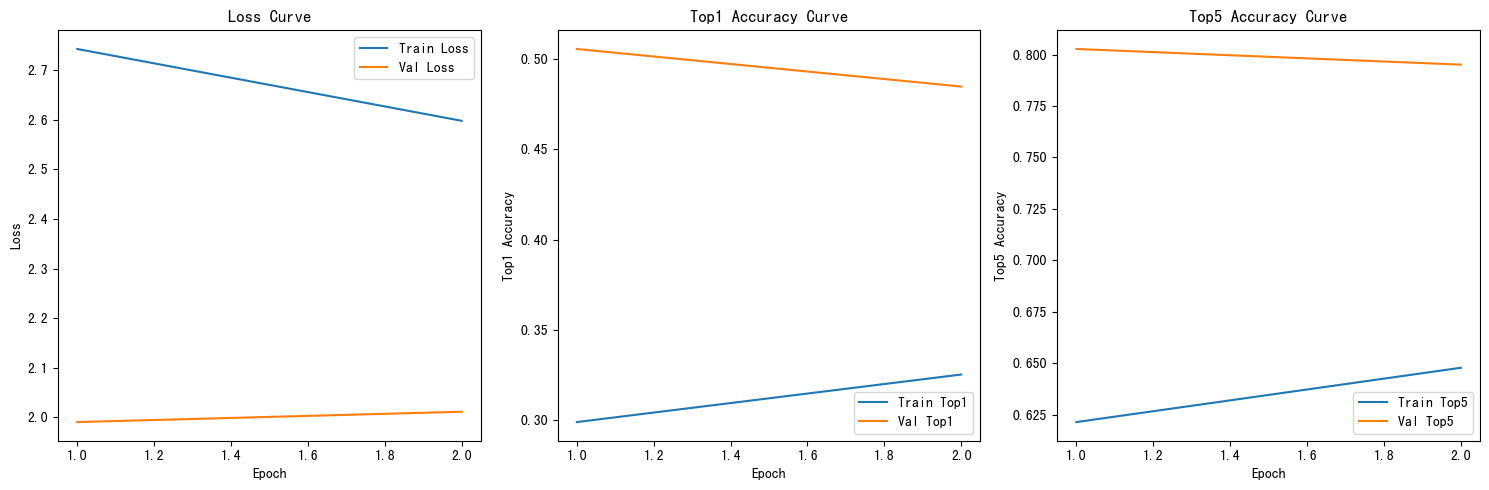

<Figure size 640x480 with 0 Axes>

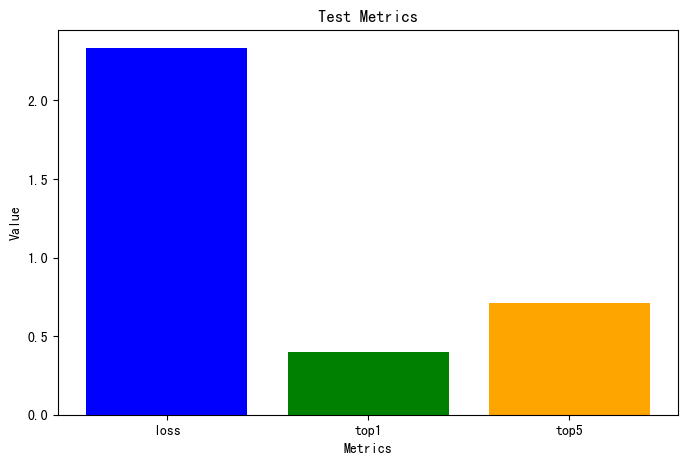

<Figure size 640x480 with 0 Axes>

In [1]:
from utils import logshow
    
logshow('logs/CNN/log_4/training_log.json', save_path='images/')
